In [ ]:
%pip install -q transformers datasets sentencepiece accelerate pandas textstat rouge-score bert-score sacrebleu

Columns found:
['example_id', 'act_name', 'section_id', 'unit_label', 'unit_type', 'page_start', 'source_text', 'has_modal', 'has_exception', 'has_numbers', 'has_roles', 'needs_context', 'bad_fragment', 'simple_text', 'split', 'notes', 'pilot_category', 'llama3.2_output', 'qwen3_output', 'mistral_output', 'gemma_output', 'flan_t5_output', 'bart_output']

Number of rows: 20
Per-row metrics preview:


,source_text,source_fkgl,source_ari,simple_text,gold_fkgl,gold_ari
0,Whoever does anything with the intention of ca...,13.611538,13.606071,A person acts dishonestly if they intend to ca...,9.830526,9.884737
1,A person who. by willful misrepresentation or ...,11.494545,11.621364,A person instigates an act if they deliberatel...,14.443636,14.909091
2,A person is said to lose wrongfully when such...,13.451429,14.269643,A person does not only lose property wrongfull...,9.796515,9.799091
3,When an offence is committed by means of sever...,18.931892,21.001892,f a crime is carried out through a series of s...,14.801212,15.121143
4,A person is said to cause an effect 'voluntari...,17.693333,20.014667,A person acts voluntarily if they meant to bri...,8.588421,9.017105
5,Sentence of death shall not be pronounced on o...,14.558582,16.550149,A pregnant woman cannot be sentenced to death....,5.730517,4.503000
6,In every case in which a person is convicted o...,28.272063,32.423810,If someone is convicted of a crime where all t...,10.443571,11.705655
7,No female shall in any case be punished with w...,6.875000,7.912188,Women cannot be punished by whipping under any...,8.746667,8.835000
8,"Whenever any person who, if absent, would be l...",19.793478,22.765000,If a person encouraged or helped someone commi...,14.511111,18.210541
9,Whoever abets the commission of an offence by ...,19.017209,22.196047,If a person encourages or helps a crime that i...,15.399524,17.288571


Summary table:


,rows,avg_source_fkgl,avg_source_ari,avg_gold_fkgl,avg_gold_ari
0,20,22.389,25.892,11.88,12.487


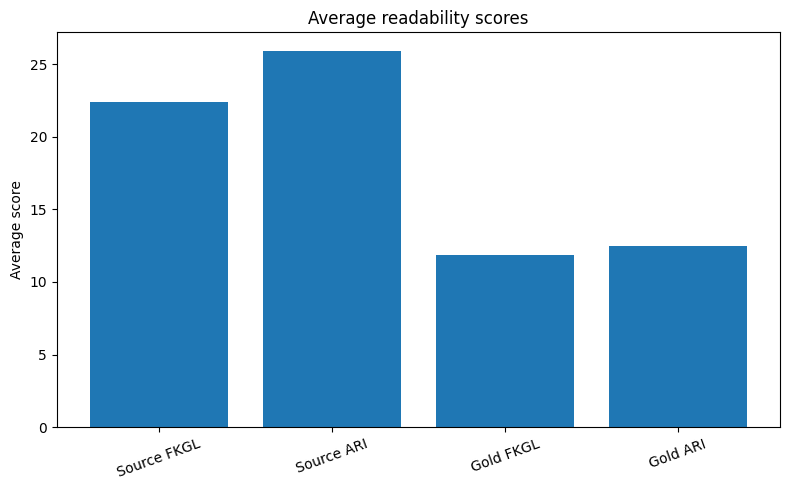

Saved files:


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from textstat import flesch_kincaid_grade, automated_readability_index

DATA_PATH = "e:/ClearClause/model_lab/data/pilot/penal_code_pilot_20.csv"

df = pd.read_csv(DATA_PATH)
print("Columns found:")
print(df.columns.tolist())
print("\nNumber of rows:", len(df))
df.head()

# ---------- helper functions ----------
def safe_fkgl(text):
    text = str(text).strip()
    if not text:
        return None
    try:
        return float(flesch_kincaid_grade(text))
    except Exception:
        return None

def safe_ari(text):
    text = str(text).strip()
    if not text:
        return None
    try:
        return float(automated_readability_index(text))
    except Exception:
        return None

# ---------- per-row source metrics ----------
df["source_fkgl"] = df["source_text"].apply(safe_fkgl)
df["source_ari"] = df["source_text"].apply(safe_ari)

# Optional: also calculate gold/human simplification metrics if simple_text exists
if "simple_text" in df.columns:
    df["gold_fkgl"] = df["simple_text"].apply(safe_fkgl)
    df["gold_ari"] = df["simple_text"].apply(safe_ari)

# ---------- averages ----------
summary = {
    "rows": len(df),
    "avg_source_fkgl": round(pd.to_numeric(df["source_fkgl"], errors="coerce").dropna().mean(), 3),
    "avg_source_ari": round(pd.to_numeric(df["source_ari"], errors="coerce").dropna().mean(), 3),
}

if "simple_text" in df.columns:
    summary["avg_gold_fkgl"] = round(pd.to_numeric(df["gold_fkgl"], errors="coerce").dropna().mean(), 3)
    summary["avg_gold_ari"] = round(pd.to_numeric(df["gold_ari"], errors="coerce").dropna().mean(), 3)

summary_df = pd.DataFrame([summary])

# ---------- save separate files ----------
df.to_csv("e:/ClearClause/model_lab/results/source_reference_metrics_per_row.csv", index=False)
summary_df.to_csv("e:/ClearClause/model_lab/results/source_reference_metrics_summary.csv", index=False)

# ---------- show tables ----------
print("Per-row metrics preview:")
display_cols = ["source_text", "source_fkgl", "source_ari"]
if "simple_text" in df.columns:
    display_cols += ["simple_text", "gold_fkgl", "gold_ari"]

display(df[display_cols].head(10))

print("Summary table:")
display(summary_df)

# ---------- chart ----------
plot_data = {
    "Source FKGL": summary["avg_source_fkgl"],
    "Source ARI": summary["avg_source_ari"],
}

if "simple_text" in df.columns:
    plot_data["Gold FKGL"] = summary["avg_gold_fkgl"]
    plot_data["Gold ARI"] = summary["avg_gold_ari"]

plt.figure(figsize=(8, 5))
plt.bar(plot_data.keys(), plot_data.values())
plt.ylabel("Average score")
plt.title("Average readability scores")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

print("Saved files:")
